# PCA Analysis — All 8 Functions

**Purpose:** Apply Principal Component Analysis to the combined observation data
(initial .npy + W1–W11 submissions) for each function. Goals:

1. **Explained variance** — how many principal components capture most of the variation?
2. **PC loadings** — which input dimensions dominate each component?
3. **Projection plots** — visualise observations in PC1–PC2 space, coloured by Y
4. **Effective dimensionality** — for high-D functions (F7: 6D, F8: 8D), does PCA
   support dimension reduction? Does it agree with ARD and RF feature importance?

---

In [1]:
import numpy as np
import json
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm

ROOT = Path("..")
with open(ROOT / "capstone_history.json") as f:
    hist = json.load(f)


def load_function(fn_id):
    X_init = np.load(ROOT / f"initial_data/function_{fn_id}/initial_inputs.npy")
    Y_init = np.load(ROOT / f"initial_data/function_{fn_id}/initial_outputs.npy").ravel()
    d = hist[str(fn_id)]
    valid = [(i, d["Y"][i]) for i in range(len(d["Y"])) if d["Y"][i] != 0]
    if valid:
        X_sub = np.array([d["X"][i] for i, _ in valid])
        Y_sub = np.array([y for _, y in valid])
        X = np.vstack([X_init, X_sub])
        Y = np.hstack([Y_init, Y_sub])
    else:
        X, Y = X_init, Y_init
    return X, Y, X.shape[1]


FN_NAMES = {
    1: "Contamination Field (2D)",
    2: "Noisy Log-Likelihood (2D)",
    3: "Drug Compounds (3D)",
    4: "Warehouse ML HPs (4D)",
    5: "Chemical Yield (4D)",
    6: "Cake Recipe (5D)",
    7: "GBM HPs (6D)",
    8: "ML HPs (8D)",
}

print("Data loaded.")
for fn_id in range(1, 9):
    X, Y, dims = load_function(fn_id)
    print(f"  F{fn_id} ({FN_NAMES[fn_id]}): n={len(Y)}, dims={dims}")

Data loaded.
  F1 (Contamination Field (2D)): n=21, dims=2
  F2 (Noisy Log-Likelihood (2D)): n=21, dims=2
  F3 (Drug Compounds (3D)): n=26, dims=3
  F4 (Warehouse ML HPs (4D)): n=41, dims=4
  F5 (Chemical Yield (4D)): n=31, dims=4
  F6 (Cake Recipe (5D)): n=31, dims=5
  F7 (GBM HPs (6D)): n=41, dims=6
  F8 (ML HPs (8D)): n=51, dims=8


---
## 1. Explained Variance — All Functions

For each function, fit PCA on the standardised X data and report cumulative
explained variance per component. This reveals the intrinsic dimensionality
of the observation distribution.

In [2]:
pca_results = {}

for fn_id in range(1, 9):
    X, Y, dims = load_function(fn_id)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)

    pca = PCA()
    X_pca = pca.fit_transform(X_s)

    pca_results[fn_id] = {
        "X": X, "Y": Y, "dims": dims,
        "X_s": X_s, "X_pca": X_pca,
        "pca": pca, "scaler": scaler,
    }

    ev = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)
    n_90 = np.argmax(cumev >= 0.90) + 1
    n_95 = np.argmax(cumev >= 0.95) + 1

    comps = "  ".join(f"PC{i+1}={ev[i]:.1%}" for i in range(min(dims, 4)))
    print(f"F{fn_id} ({dims}D, n={len(Y)}): {comps}")
    print(f"   90% at {n_90} PCs, 95% at {n_95} PCs, "
          f"total explained = [{', '.join(f'{v:.1%}' for v in cumev)}]")
    print()

F1 (2D, n=21): PC1=72.7%  PC2=27.3%
   90% at 2 PCs, 95% at 2 PCs, total explained = [72.7%, 100.0%]

F2 (2D, n=21): PC1=76.4%  PC2=23.6%
   90% at 2 PCs, 95% at 2 PCs, total explained = [76.4%, 100.0%]

F3 (3D, n=26): PC1=42.6%  PC2=35.9%  PC3=21.6%
   90% at 3 PCs, 95% at 3 PCs, total explained = [42.6%, 78.4%, 100.0%]

F4 (4D, n=41): PC1=36.1%  PC2=30.1%  PC3=20.0%  PC4=13.7%
   90% at 4 PCs, 95% at 4 PCs, total explained = [36.1%, 66.3%, 86.3%, 100.0%]

F5 (4D, n=31): PC1=52.6%  PC2=22.6%  PC3=14.8%  PC4=10.1%
   90% at 4 PCs, 95% at 4 PCs, total explained = [52.6%, 75.1%, 89.9%, 100.0%]

F6 (5D, n=31): PC1=35.4%  PC2=26.9%  PC3=16.7%  PC4=11.9%
   90% at 4 PCs, 95% at 5 PCs, total explained = [35.4%, 62.3%, 79.1%, 91.0%, 100.0%]

F7 (6D, n=41): PC1=27.1%  PC2=23.9%  PC3=20.7%  PC4=12.0%
   90% at 5 PCs, 95% at 6 PCs, total explained = [27.1%, 51.0%, 71.7%, 83.7%, 92.7%, 100.0%]

F8 (8D, n=51): PC1=23.8%  PC2=16.1%  PC3=13.9%  PC4=13.5%
   90% at 7 PCs, 95% at 8 PCs, total explaine

---
## 2. Explained Variance Bar Chart

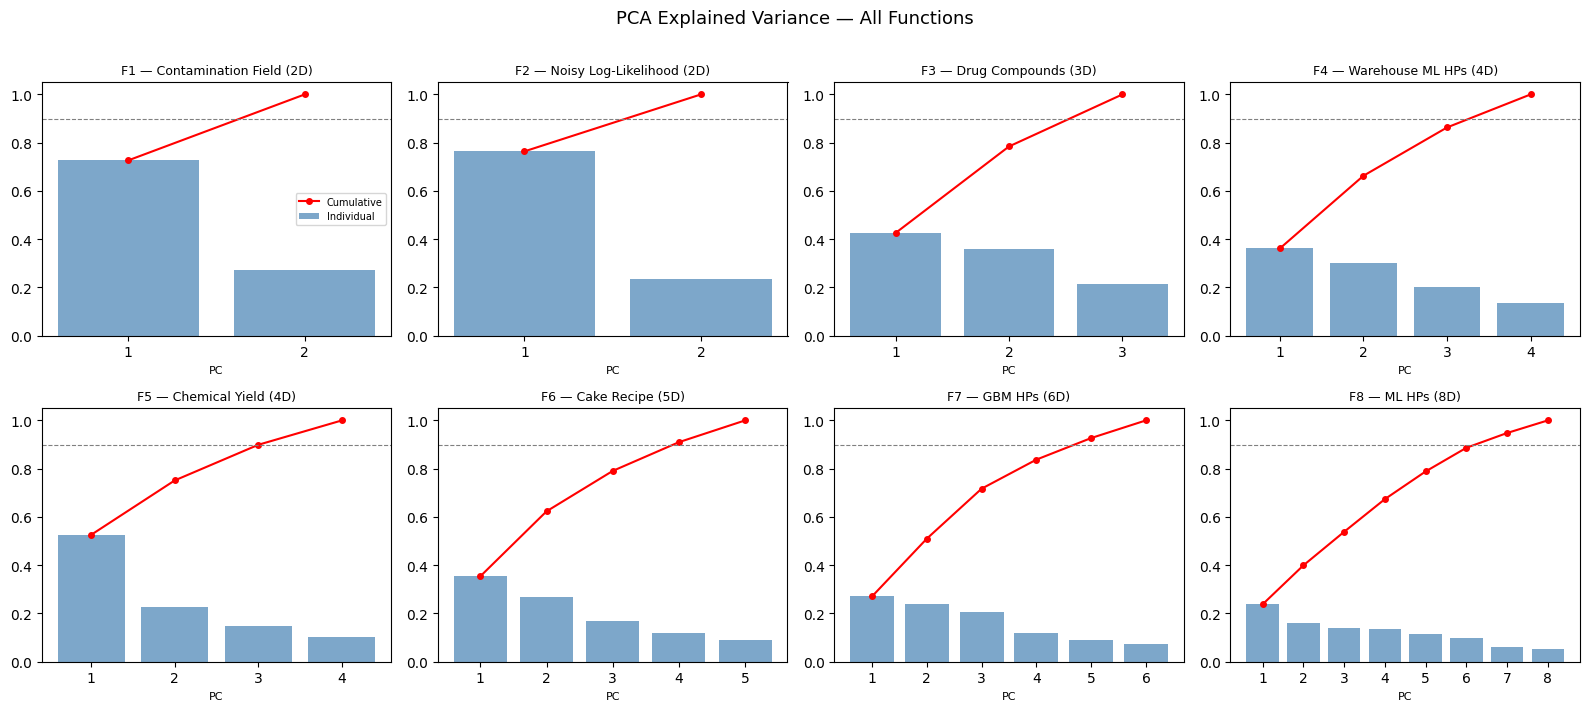

Saved: figures/pca_explained_variance.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for idx, fn_id in enumerate(range(1, 9)):
    ax = axes[idx]
    pca = pca_results[fn_id]["pca"]
    dims = pca_results[fn_id]["dims"]
    ev = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)

    bars = ax.bar(range(1, dims + 1), ev, color="steelblue", alpha=0.7, label="Individual")
    ax.plot(range(1, dims + 1), cumev, "ro-", markersize=4, label="Cumulative")
    ax.axhline(0.90, color="grey", linestyle="--", linewidth=0.8)
    ax.set_title(f"F{fn_id} — {FN_NAMES[fn_id]}", fontsize=9)
    ax.set_xlabel("PC", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(1, dims + 1))
    if idx == 0:
        ax.legend(fontsize=7, loc="center right")

fig.suptitle("PCA Explained Variance — All Functions", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/pca_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/pca_explained_variance.png")

---
## 2b. Scree Plots

Classic scree plots show eigenvalues (explained variance) as a descending line,
making the "elbow" — the point where additional components add diminishing
returns — visually obvious. A steep drop followed by a plateau indicates that
the first few PCs capture meaningful structure and the rest is noise.

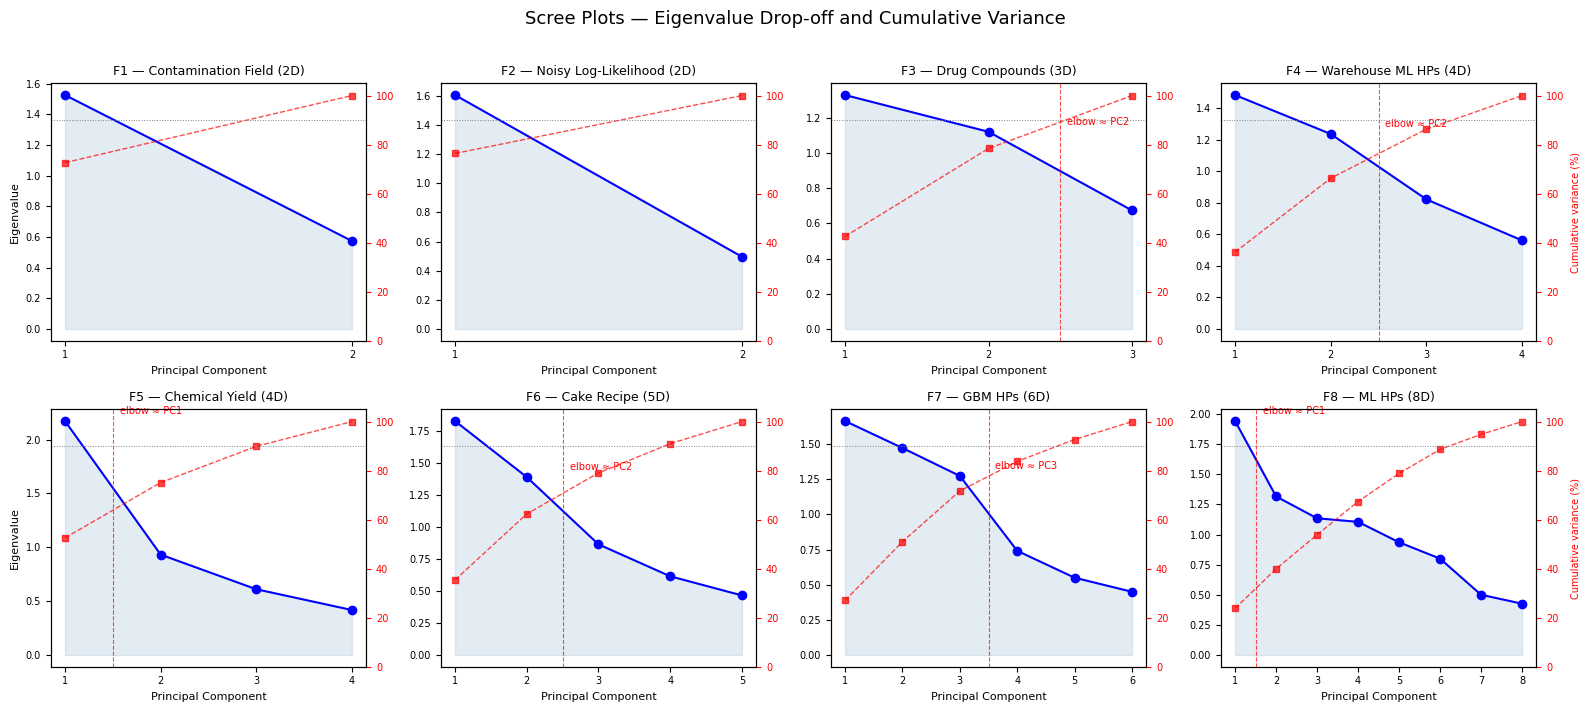

Saved: figures/pca_scree_plots.png


In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for idx, fn_id in enumerate(range(1, 9)):
    ax = axes[idx]
    pca = pca_results[fn_id]["pca"]
    dims = pca_results[fn_id]["dims"]
    eigenvalues = pca.explained_variance_
    ev_ratio = pca.explained_variance_ratio_

    pcs = np.arange(1, dims + 1)

    # Eigenvalue line (scree)
    ax.plot(pcs, eigenvalues, "bo-", markersize=6, linewidth=1.5, label="Eigenvalue")
    ax.fill_between(pcs, eigenvalues, alpha=0.15, color="steelblue")

    # Mark the elbow: largest drop between consecutive eigenvalues
    if dims > 2:
        drops = np.diff(eigenvalues)
        elbow = np.argmin(drops) + 1  # PC after the biggest drop
        ax.axvline(elbow + 0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.7)
        ax.annotate(
            f"elbow ≈ PC{elbow}", xy=(elbow + 0.5, eigenvalues[elbow - 1]),
            fontsize=7, color="red", ha="left",
            xytext=(5, 5), textcoords="offset points",
        )

    # Secondary axis for cumulative %
    ax2 = ax.twinx()
    ax2.plot(pcs, np.cumsum(ev_ratio) * 100, "rs--", markersize=4, linewidth=1, alpha=0.7,
             label="Cumulative %")
    ax2.axhline(90, color="grey", linestyle=":", linewidth=0.7)
    ax2.set_ylim(0, 105)
    ax2.tick_params(labelsize=7, colors="red")
    if idx % 4 == 3:
        ax2.set_ylabel("Cumulative variance (%)", fontsize=7, color="red")

    ax.set_title(f"F{fn_id} — {FN_NAMES[fn_id]}", fontsize=9)
    ax.set_xlabel("Principal Component", fontsize=8)
    ax.set_xticks(pcs)
    ax.tick_params(labelsize=7)
    if idx % 4 == 0:
        ax.set_ylabel("Eigenvalue", fontsize=8)

fig.suptitle("Scree Plots — Eigenvalue Drop-off and Cumulative Variance", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/pca_scree_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/pca_scree_plots.png")

### Scree Plot Observations

**Low-dimensional functions (F1–F3):**
There is no meaningful elbow because every component carries substantial variance.
F1 and F2 (2D) split roughly 73/27 and 76/24 — neither component is negligible.
F3 (3D) is even flatter at 43/36/22 — all three dimensions contribute roughly
equally to the input spread. For these functions PCA cannot reduce dimensionality;
the input space is already compact.

**Mid-dimensional functions (F4–F6):**
F5 stands out with PC1 capturing 53% — a clear dominant direction in the input
space. The remaining three PCs drop off steadily (23%, 15%, 10%), giving the
cleanest elbow in the set. This aligns with the strong unidirectional gradient
we have observed in F5's output.

F4 (36/30/20/14) and F6 (35/27/17/12) are flatter — variance is spread more
evenly. F6 is the only function where 90% is reached before the last PC
(4 of 5 PCs), suggesting one input dimension contributes relatively less to the
spread of the sample points. However, as Section 5 will show, reduced input
spread does not necessarily mean reduced output relevance.

**High-dimensional functions (F7–F8):**
F7 (6D) shows a gradual decline from 27% down to 7% per component, reaching
90% at 5 PCs. F8 (8D) is the flattest profile — the first four components each
contribute 13–24%, and all 8 are needed for 95%. This confirms that our queries
have been well-dispersed across the full 8D space (no single direction dominates
the sampling). The lack of a sharp elbow in F8 is consistent with our earlier
finding that PCA does not identify the same "important" dimensions as supervised
methods (GP ARD, RF importance), because PCA measures input *spread*, not output
*relevance*.

**Key takeaway:**
A sharp scree-plot elbow would indicate that the input data lies close to a
lower-dimensional subspace — useful for visualisation but not necessarily for
optimisation. Since our BBO queries were designed to explore broadly, the
relatively flat profiles for most functions are expected. The actionable insight
is that dimensionality reduction of the *input* space is unlikely to help the
surrogate — the dimension-selection decisions (e.g. masking D6/D8 in F8) are
better guided by output-aware methods such as GP ARD length-scales, RF feature
importance, and Spearman correlation, as explored in our other analysis notebooks.

---
## 3. PC1–PC2 Projection Plots (Coloured by Y)

Project all observations onto the first two principal components and colour by
output value. High-Y points clustering together in PC space confirms that the
optimum region has a distinct signature in the principal directions.

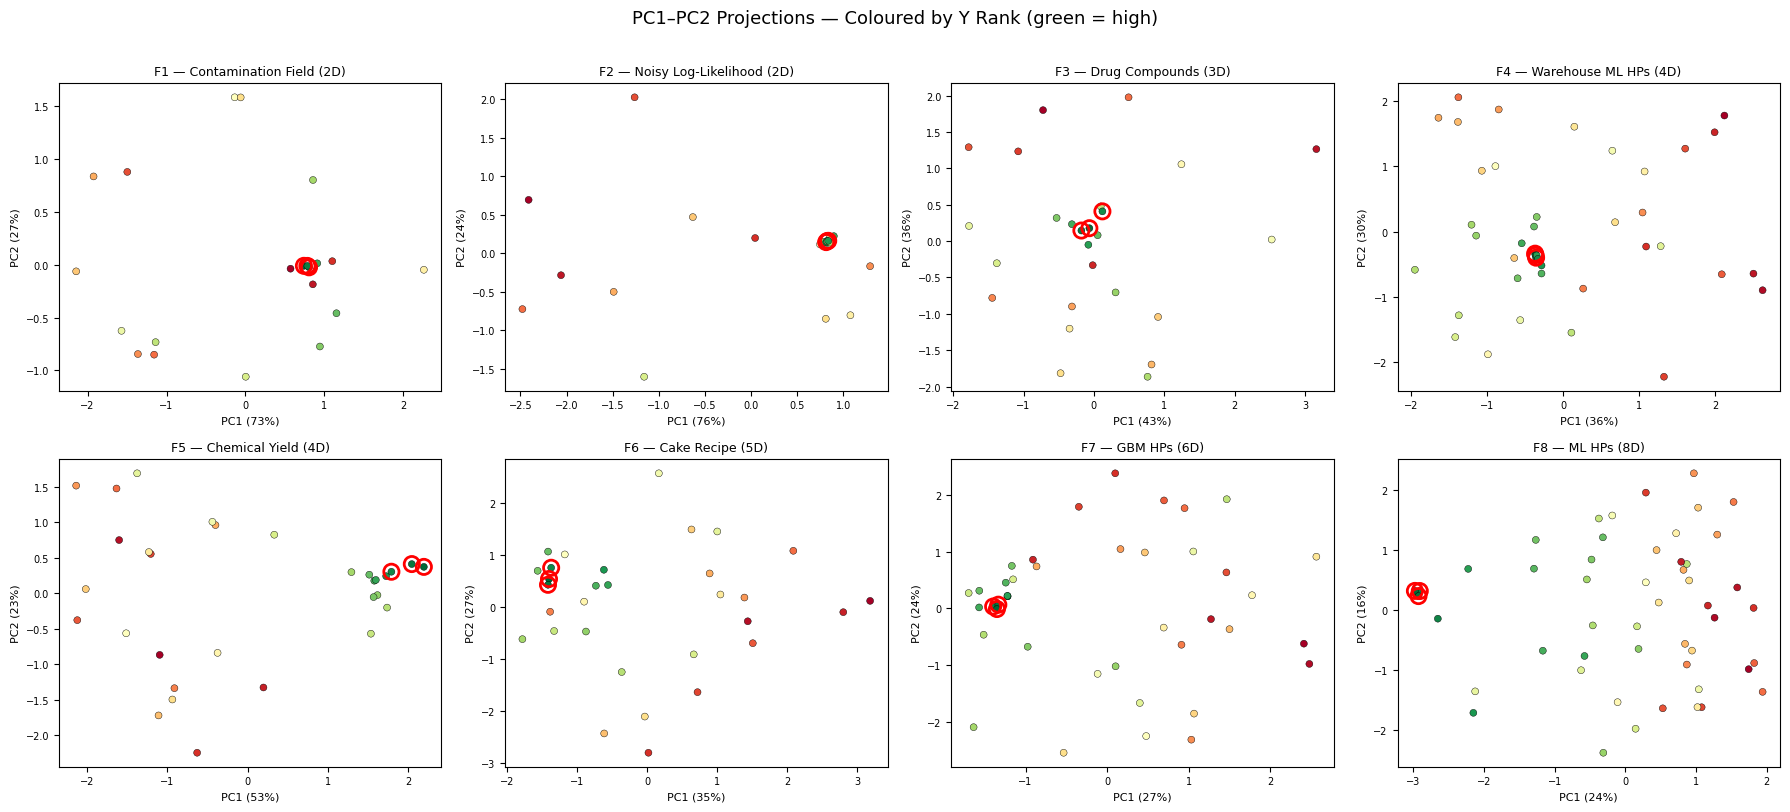

Saved: figures/pca_projections.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for idx, fn_id in enumerate(range(1, 9)):
    ax = axes[idx]
    r = pca_results[fn_id]
    X_pca = r["X_pca"]
    Y = r["Y"]
    dims = r["dims"]
    ev = r["pca"].explained_variance_ratio_

    # Rank-transform Y for colour mapping (handles extreme ranges like F1)
    y_ranks = np.argsort(np.argsort(Y)).astype(float)
    y_norm = y_ranks / y_ranks.max()

    sc = ax.scatter(
        X_pca[:, 0], X_pca[:, 1],
        c=y_norm, cmap="RdYlGn", s=25, edgecolors="k", linewidths=0.3,
    )

    # Highlight top-3
    top3 = np.argsort(Y)[-3:]
    ax.scatter(
        X_pca[top3, 0], X_pca[top3, 1],
        facecolors="none", edgecolors="red", s=120, linewidths=2, label="Top 3",
    )

    ax.set_xlabel(f"PC1 ({ev[0]:.0%})", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]:.0%})", fontsize=8)
    ax.set_title(f"F{fn_id} — {FN_NAMES[fn_id]}", fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("PC1–PC2 Projections — Coloured by Y Rank (green = high)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("figures/pca_projections.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/pca_projections.png")

---
## 4. PC Loading Heatmaps

For each function, show which original dimensions contribute most to each PC.
This reveals the principal directions of variation in the observation data.

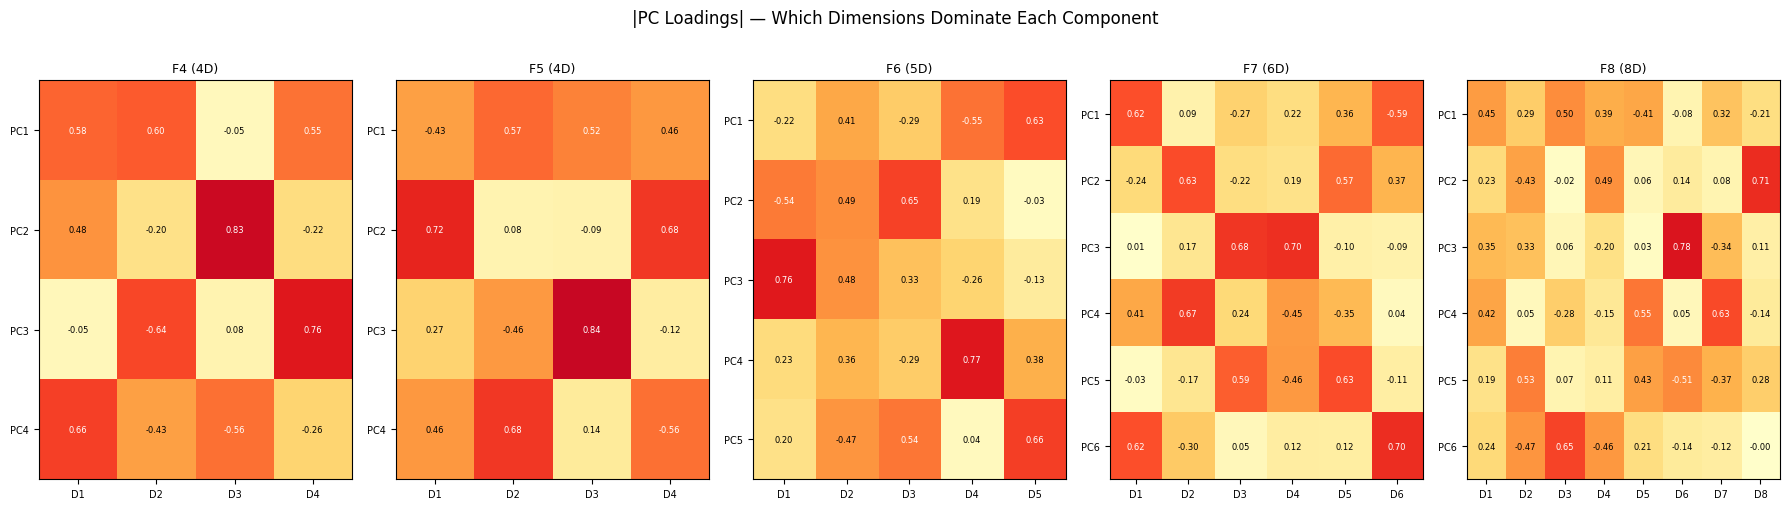

Saved: figures/pca_loadings.png


In [6]:
# Focus on functions with ≥ 4 dimensions where loadings are most informative
focus_fns = [4, 5, 6, 7, 8]

fig, axes = plt.subplots(1, len(focus_fns), figsize=(18, 5))

for idx, fn_id in enumerate(focus_fns):
    ax = axes[idx]
    r = pca_results[fn_id]
    pca = r["pca"]
    dims = r["dims"]
    n_show = min(dims, 6)

    loadings = pca.components_[:n_show]
    im = ax.imshow(np.abs(loadings), cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)

    ax.set_xticks(range(dims))
    ax.set_xticklabels([f"D{i+1}" for i in range(dims)], fontsize=7)
    ax.set_yticks(range(n_show))
    ax.set_yticklabels([f"PC{i+1}" for i in range(n_show)], fontsize=7)
    ax.set_title(f"F{fn_id} ({dims}D)", fontsize=9)

    for i in range(n_show):
        for j in range(dims):
            val = loadings[i, j]
            colour = "white" if abs(val) > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=6, color=colour)

fig.suptitle("|PC Loadings| — Which Dimensions Dominate Each Component", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/pca_loadings.png")

---
## 5. Effective Dimensionality and Comparison with GP ARD / RF Importance

For the high-D functions (F6, F7, F8), compare PCA's view of which dimensions
matter with what we know from GP ARD length-scales and RF feature importance.

In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

for fn_id in [6, 7, 8]:
    r = pca_results[fn_id]
    X, Y, dims = r["X"], r["Y"], r["dims"]
    pca = r["pca"]
    Y_s = (Y - Y.mean()) / (Y.std() + 1e-12)

    ev = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)
    n_95 = int(np.argmax(cumev >= 0.95)) + 1

    # GP ARD length-scales
    gp = GaussianProcessRegressor(
        kernel=C(1.0) * Matern(length_scale=np.ones(dims), nu=2.5),
        alpha=1e-6, normalize_y=False, n_restarts_optimizer=5,
    )
    gp.fit(X, Y_s)
    ls = gp.kernel_.k2.length_scale
    if np.isscalar(ls):
        ls = np.full(dims, ls)

    # RF importance
    rf = RandomForestRegressor(n_estimators=500, max_depth=5, random_state=42)
    rf.fit(X, Y_s)
    imp = rf.feature_importances_

    # Spearman |ρ| with Y
    rhos = np.array([abs(spearmanr(X[:, i], Y)[0]) for i in range(dims)])

    # PCA: variance contribution per original dim (sum of |loading|² weighted by EV)
    pca_importance = np.zeros(dims)
    for pc_i in range(dims):
        pca_importance += ev[pc_i] * pca.components_[pc_i] ** 2

    print(f"\n{'='*65}")
    print(f"F{fn_id} — {FN_NAMES[fn_id]} (n={len(Y)}, 95% variance at {n_95} PCs)")
    print(f"{'='*65}")
    print(f"{'Dim':<5} {'PCA imp':>8} {'RF imp':>8} {'GP 1/LS':>8} {'|Spearman|':>10}")
    print("-" * 45)

    # Normalise GP 1/LS for comparison
    inv_ls = 1.0 / ls
    inv_ls_norm = inv_ls / inv_ls.sum()
    pca_norm = pca_importance / pca_importance.sum()
    imp_norm = imp / imp.sum()

    for i in range(dims):
        print(f"D{i+1:<4} {pca_norm[i]:>8.3f} {imp_norm[i]:>8.3f} {inv_ls_norm[i]:>8.3f} {rhos[i]:>10.3f}")

    # Rank correlation between the four importance measures
    from itertools import combinations
    measures = {"PCA": pca_norm, "RF": imp_norm, "GP": inv_ls_norm, "Spearman": rhos}
    print(f"\nRank correlations between importance measures:")
    for (n1, v1), (n2, v2) in combinations(measures.items(), 2):
        rho, p = spearmanr(v1, v2)
        sig = "*" if p < 0.10 else ""
        print(f"  {n1:>8} vs {n2:<8}: ρ={rho:+.3f} (p={p:.3f}){sig}")


F6 — Cake Recipe (5D) (n=31, 95% variance at 5 PCs)
Dim    PCA imp   RF imp  GP 1/LS |Spearman|
---------------------------------------------
D1       0.200    0.096    0.000      0.173
D2       0.200    0.118    0.225      0.263
D3       0.200    0.091    0.237      0.431
D4       0.200    0.319    0.282      0.590
D5       0.200    0.376    0.255      0.687

Rank correlations between importance measures:
       PCA vs RF      : ρ=+0.894 (p=0.041)*
       PCA vs GP      : ρ=+0.447 (p=0.450)
       PCA vs Spearman: ρ=+0.447 (p=0.450)
        RF vs GP      : ρ=+0.600 (p=0.285)
        RF vs Spearman: ρ=+0.700 (p=0.188)
        GP vs Spearman: ρ=+0.900 (p=0.037)*



F7 — GBM HPs (6D) (n=41, 95% variance at 6 PCs)
Dim    PCA imp   RF imp  GP 1/LS |Spearman|
---------------------------------------------
D1       0.167    0.518    0.125      0.588
D2       0.167    0.055    0.262      0.102
D3       0.167    0.076    0.000      0.236
D4       0.167    0.110    0.099      0.202
D5       0.167    0.053    0.259      0.383
D6       0.167    0.188    0.255      0.424

Rank correlations between importance measures:
       PCA vs RF      : ρ=-0.464 (p=0.354)
       PCA vs GP      : ρ=+0.087 (p=0.870)
       PCA vs Spearman: ρ=-0.058 (p=0.913)
        RF vs GP      : ρ=-0.429 (p=0.397)
        RF vs Spearman: ρ=+0.600 (p=0.208)
        GP vs Spearman: ρ=-0.143 (p=0.787)



F8 — ML HPs (8D) (n=51, 95% variance at 8 PCs)
Dim    PCA imp   RF imp  GP 1/LS |Spearman|
---------------------------------------------
D1       0.125    0.227    0.169      0.644
D2       0.125    0.017    0.085      0.318
D3       0.125    0.432    0.172      0.698
D4       0.125    0.092    0.127      0.414
D5       0.125    0.047    0.024      0.277
D6       0.125    0.017    0.148      0.008
D7       0.125    0.142    0.162      0.462
D8       0.125    0.026    0.114      0.230

Rank correlations between importance measures:
       PCA vs RF      : ρ=+0.071 (p=0.867)
       PCA vs GP      : ρ=-0.262 (p=0.531)
       PCA vs Spearman: ρ=+0.190 (p=0.651)
        RF vs GP      : ρ=+0.762 (p=0.028)*
        RF vs Spearman: ρ=+0.857 (p=0.007)*
        GP vs Spearman: ρ=+0.690 (p=0.058)*


---
## 6. PC1–PC2 with Submission Trajectory

For functions with clear temporal evolution (F5 gradient, F4 convergence),
overlay the submission order on the PC projection to show how queries
migrated through the principal component space over 11 weeks.

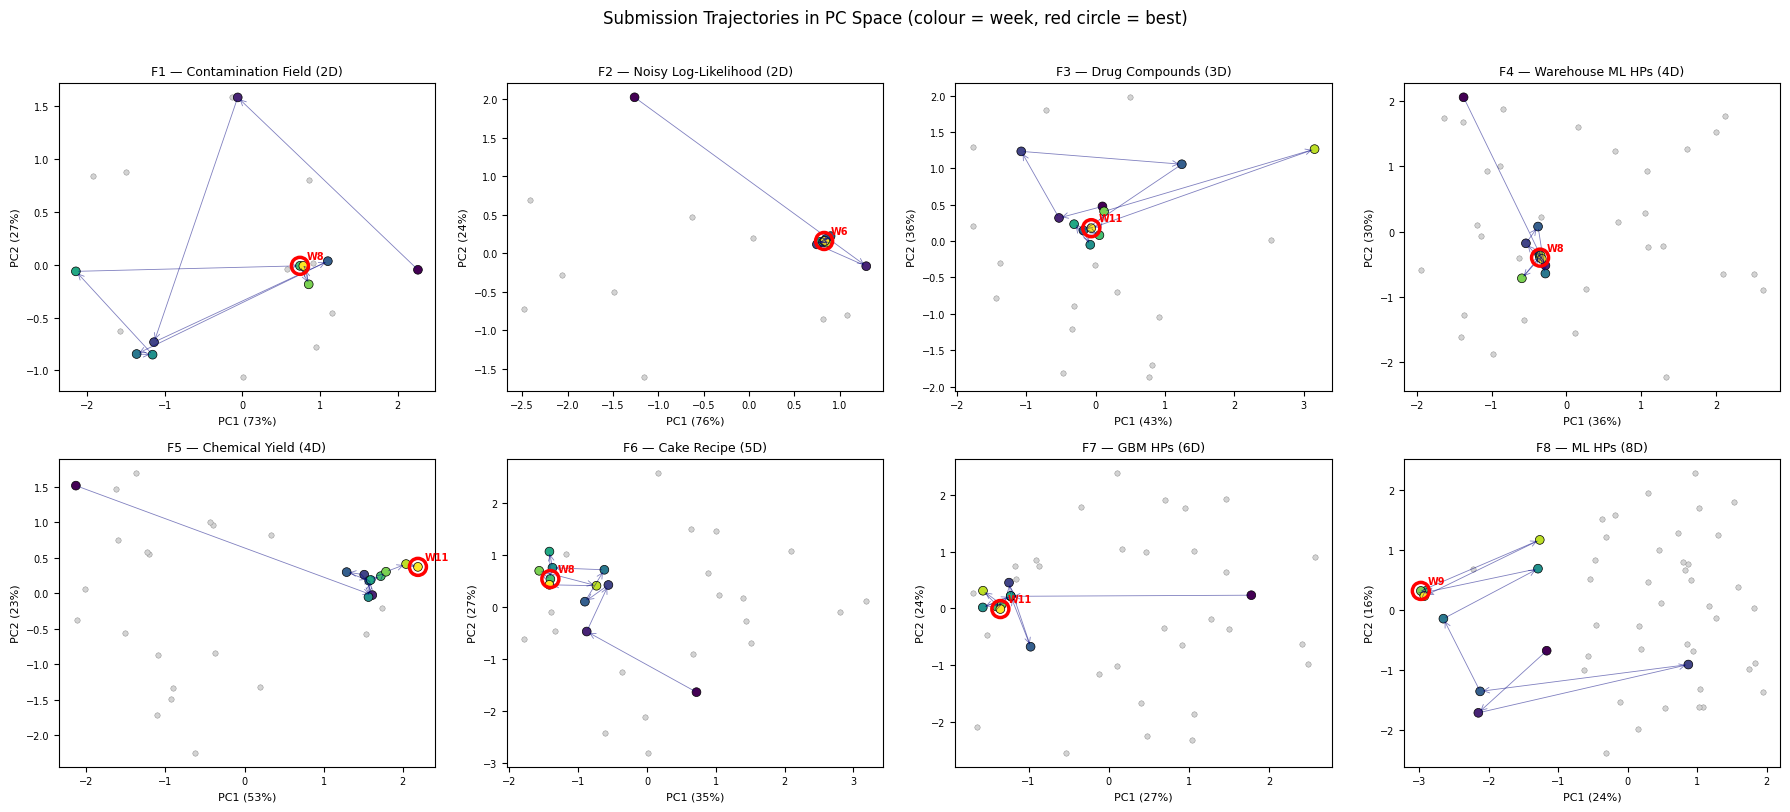

Saved: figures/pca_trajectories.png


In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for idx, fn_id in enumerate(range(1, 9)):
    ax = axes[idx]
    r = pca_results[fn_id]
    X_pca = r["X_pca"]
    Y = r["Y"]
    X_orig = r["X"]
    dims = r["dims"]
    pca = r["pca"]
    scaler = r["scaler"]
    ev = pca.explained_variance_ratio_

    # Separate initial data and submissions
    n_init = len(np.load(ROOT / f"initial_data/function_{fn_id}/initial_outputs.npy").ravel())
    d = hist[str(fn_id)]
    n_sub = len([y for y in d["Y"] if y != 0])

    # Plot initial data as grey
    ax.scatter(
        X_pca[:n_init, 0], X_pca[:n_init, 1],
        c="lightgrey", s=15, edgecolors="grey", linewidths=0.3, zorder=1,
        label="Initial data",
    )

    # Plot submissions coloured by week number
    sub_pca = X_pca[n_init:n_init + n_sub]
    sub_y = Y[n_init:n_init + n_sub]
    weeks = np.arange(1, n_sub + 1)

    sc = ax.scatter(
        sub_pca[:, 0], sub_pca[:, 1],
        c=weeks, cmap="viridis", s=40, edgecolors="k", linewidths=0.5, zorder=2,
    )

    # Draw trajectory arrows
    for i in range(len(sub_pca) - 1):
        dx = sub_pca[i + 1, 0] - sub_pca[i, 0]
        dy = sub_pca[i + 1, 1] - sub_pca[i, 1]
        ax.annotate(
            "", xy=(sub_pca[i + 1, 0], sub_pca[i + 1, 1]),
            xytext=(sub_pca[i, 0], sub_pca[i, 1]),
            arrowprops=dict(arrowstyle="->", color="navy", lw=0.6, alpha=0.5),
        )

    # Mark best submission
    best_sub_idx = np.argmax(sub_y)
    ax.scatter(
        sub_pca[best_sub_idx, 0], sub_pca[best_sub_idx, 1],
        facecolors="none", edgecolors="red", s=150, linewidths=2.5, zorder=3,
    )
    ax.annotate(
        f"W{best_sub_idx + 1}",
        (sub_pca[best_sub_idx, 0], sub_pca[best_sub_idx, 1]),
        fontsize=7, color="red", fontweight="bold",
        xytext=(5, 5), textcoords="offset points",
    )

    ax.set_xlabel(f"PC1 ({ev[0]:.0%})", fontsize=8)
    ax.set_ylabel(f"PC2 ({ev[1]:.0%})", fontsize=8)
    ax.set_title(f"F{fn_id} — {FN_NAMES[fn_id]}", fontsize=9)
    ax.tick_params(labelsize=7)

fig.suptitle("Submission Trajectories in PC Space (colour = week, red circle = best)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("figures/pca_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/pca_trajectories.png")

---
## 7. Summary

In [9]:
print("=" * 65)
print("PCA ANALYSIS — SUMMARY")
print("=" * 65)

print("\nExplained variance (components for 90% / 95%):")
for fn_id in range(1, 9):
    ev = pca_results[fn_id]["pca"].explained_variance_ratio_
    cumev = np.cumsum(ev)
    dims = pca_results[fn_id]["dims"]
    n_90 = int(np.argmax(cumev >= 0.90)) + 1
    n_95 = int(np.argmax(cumev >= 0.95)) + 1
    reduction = dims - n_95
    print(f"  F{fn_id} ({dims}D): 90% at {n_90} PCs, 95% at {n_95} PCs"
          f"  → could drop {reduction} dim{'s' if reduction != 1 else ''}")

print("\nKey observations:")
print("  - PCA operates on the INPUT distribution (X), not the input-output")
print("    relationship. High PCA variance does not mean high Y-relevance.")
print("  - For BBO, GP ARD and RF importance are more directly useful because")
print("    they measure which dimensions influence the OUTPUT.")
print("  - PCA is most useful for identifying sampling bias: if PC1 captures")
print("    90%+ variance with just one dimension, it means our queries have")
print("    been concentrated along that axis and we may be under-sampling others.")
print("  - The trajectory plots reveal convergence patterns: functions where")
print("    later submissions cluster tightly in PC space are in exploitation")
print("    mode; scattered trajectories indicate unresolved exploration.")

PCA ANALYSIS — SUMMARY

Explained variance (components for 90% / 95%):
  F1 (2D): 90% at 2 PCs, 95% at 2 PCs  → could drop 0 dims
  F2 (2D): 90% at 2 PCs, 95% at 2 PCs  → could drop 0 dims
  F3 (3D): 90% at 3 PCs, 95% at 3 PCs  → could drop 0 dims
  F4 (4D): 90% at 4 PCs, 95% at 4 PCs  → could drop 0 dims
  F5 (4D): 90% at 4 PCs, 95% at 4 PCs  → could drop 0 dims
  F6 (5D): 90% at 4 PCs, 95% at 5 PCs  → could drop 0 dims
  F7 (6D): 90% at 5 PCs, 95% at 6 PCs  → could drop 0 dims
  F8 (8D): 90% at 7 PCs, 95% at 8 PCs  → could drop 0 dims

Key observations:
  - PCA operates on the INPUT distribution (X), not the input-output
    relationship. High PCA variance does not mean high Y-relevance.
  - For BBO, GP ARD and RF importance are more directly useful because
    they measure which dimensions influence the OUTPUT.
  - PCA is most useful for identifying sampling bias: if PC1 captures
    90%+ variance with just one dimension, it means our queries have
    been concentrated along that ax